## BIT

Bayesian Inference Tool (BIT) is a python package designed to provide easy access to fitting models to data using Bayesian inference.

In [1]:
from bit import samplers
import numpy as np
import matplotlib.pyplot as plt
import corner
import tqdm

Import the linear model from `samplers`

In [ ]:
model = samplers.linear_model

Now generate fake data with noise

In [ ]:
m_true = 2.5
c_true = 1.0
x = np.linspace(0, 10, 50)
yerr = 0.5
line = model([m_true, c_true], x)
y = line + np.random.normal(0, yerr, len(x))

And plot

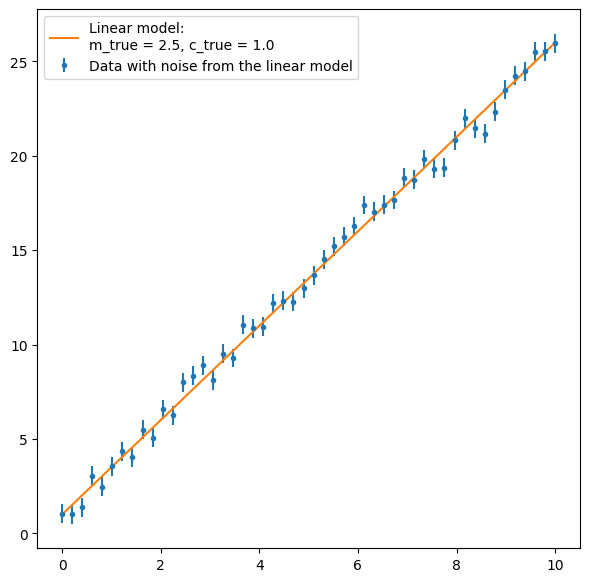

In [ ]:
fig, axes = plt.subplots(1, figsize=(7, 7))
axes.errorbar(x=x, y=y, yerr=yerr, fmt='.',
              label='Data with noise from the linear model')
axes.plot(x, line, label='Linear model: \nm_true = {}, c_true = {}'.format(
    m_true, c_true))
axes.plot()
plt.legend()
plt.show()

Fit the data with our wrapper function (soon to be callable from a python package)

Our function does everything under the hood which is easy for users

In [6]:
samples = samplers.fit(samplers.log_prob, initial_guess=[
                       1.0, 1.0], args=(x, y, yerr))

100%|██████████| 2000/2000 [00:00<00:00, 2681.49it/s]


Print results

In [7]:
res = samples.mean(axis=0)
m_fit, c_fit = [round(x, 2) for x in [res[0], res[1]]]
print(m_fit, c_fit)

2.49 1.08


Plot the results

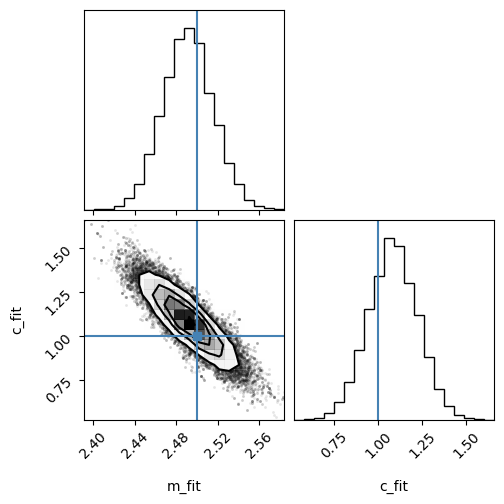

In [8]:
fig = corner.corner(
    samples, labels=['m_fit', 'c_fit'], truths=[m_true, c_true])

Plot the data with our fit values over the true value

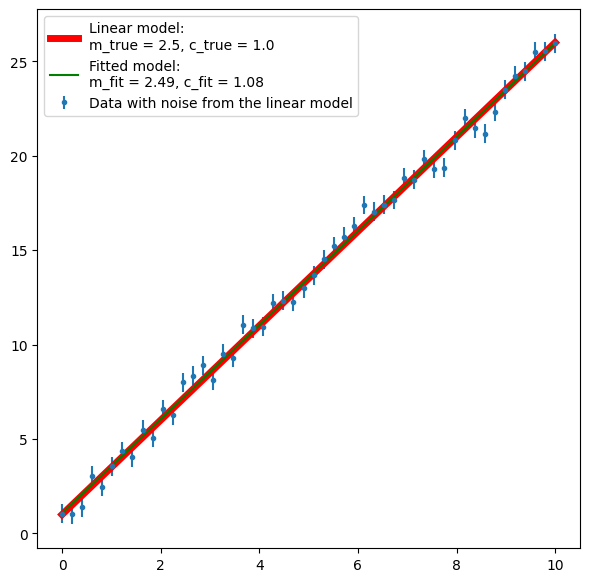

In [18]:
fig, axes = plt.subplots(1, figsize=(7, 7))
axes.errorbar(x=x, y=y, yerr=yerr, fmt='.',
              label='Data with noise from the linear model')
axes.plot(x, line, label='Linear model: \nm_true = {}, c_true = {}'.format(
    m_true, c_true), lw=5, c='red')
axes.plot(x, model([m_fit, c_fit], x), c='green',
          label='Fitted model: \nm_fit = {}, c_fit = {}'.format(m_fit, c_fit))
plt.legend()
plt.show()